# Crypto Statistical Arbitrage

**Author:** Aman Syed  
**Exchange:** Kraken (public REST API)  
**Bar frequency:** 4-hour candles  
**Strategy type:** Cointegration-based pairs trading  

---

## Overview

This notebook presents an end-to-end **crypto statistical arbitrage research pipeline**. The workflow is:

1. Load Kraken OHLC price history with local caching
2. Screen candidate pairs using **Engle-Granger**, **Johansen**, **ADF**, and **OU half-life**
3. Build a mean-reverting spread using an OLS hedge ratio
4. Generate **z-score** entry and exit signals
5. Size exposure with a **fractional Kelly** overlay
6. Run a vectorized backtest with transaction costs, slippage, and a drawdown kill-switch

The objective is not to predict outright crypto direction. Instead, the strategy looks for pairs whose **relative value relationship** appears stable and then trades temporary deviations from that equilibrium.

### Headline results (4H bars, ~4-month window, $100k capital)

From a 9-asset universe, 7 cointegrated pairs were identified. Four of them produced Sharpe ratios above 2.0 after 7bps transaction costs and 3bps slippage:

| Pair       | Ann. Return | Sharpe | Max DD  | Calmar |
|------------|-------------|--------|---------|--------|
| BTC/SOL    | 4.8%        | 3.66   | -0.3%   | 16.9   |
| XRP/AVAX   | 15.1%       | 3.49   | -0.6%   | 24.2   |
| BTC/ETH    | 4.9%        | 2.82   | -0.8%   | 6.3    |
| XRP/DOGE   | 8.8%        | 2.34   | -1.4%   | 6.4    |

BTC/SOL stands out for its near-zero drawdown profile (−0.3% max DD, Calmar 16.9). XRP/AVAX leads on raw return and Calmar. See Section 6 for the full universe results.


---
## 0. Setup & Imports

In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.ticker import FuncFormatter
from IPython.display import display

from data import load_prices, INTERVAL_4H
from cointegration import screen_pairs, compute_spread
from signals import generate_signals, SignalConfig, get_current_signal
from sizing import kelly_size, SizingConfig
from backtest import run_backtest, BacktestConfig

try:
    from main import TICKERS as MAIN_TICKERS
    TICKERS = list(MAIN_TICKERS)
except Exception:
    TICKERS = ["BTC", "ETH", "SOL", "ADA", "XRP", "DOGE", "DOT", "AVAX", "LINK"]

START_DATE     = "2023-01-01"
BAR_INTERVAL   = INTERVAL_4H      # 240 minutes = 4-hour candles
BAR_HOURS      = BAR_INTERVAL / 60.0   # 4.0  — used to convert OU half-life bars → days
LOOKBACK_BARS  = 120              # z-score lookback: 120 bars ≈ 20 calendar days at 4H
CAPITAL        = 100_000

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f9fa",
    "axes.edgecolor": "#d0d7de",
    "axes.grid": True,
    "grid.alpha": 0.18,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})


---
## 1. Market Data

This project uses **Kraken public OHLC data** with local parquet caching. The notebook is configured for **4-hour candles**, which gives a denser view of relative-value behavior than daily data while remaining readable in a presentation setting.

**Research window:** 2023-01-01 to present  
**Universe:** pulled from the project configuration (`main.py` if available)

> Note: the notebook is written to be robust to minor codebase differences, such as whether `load_prices()` currently exposes an `interval` argument.

In [7]:
prices = load_prices(
    tickers=TICKERS,
    start=START_DATE,
    interval=BAR_INTERVAL,
    refresh=False,
)

print(
    f"Loaded {len(prices):,} bars | "
    f"{prices.index[0]} → {prices.index[-1]} | "
    f"Universe: {list(prices.columns)}"
)
prices.tail()

[data] Loading BTC from cache: data/cache/BTC_240.parquet
[data] Loading ETH from cache: data/cache/ETH_240.parquet
[data] Loading SOL from cache: data/cache/SOL_240.parquet
[data] Loading ADA from cache: data/cache/ADA_240.parquet
[data] Loading XRP from cache: data/cache/XRP_240.parquet
[data] Loading DOGE from cache: data/cache/DOGE_240.parquet
[data] Loading DOT from cache: data/cache/DOT_240.parquet
[data] Loading AVAX from cache: data/cache/AVAX_240.parquet
[data] Loading LINK from cache: data/cache/LINK_240.parquet
[data] Loaded 721 aligned 240min bars for ['BTC', 'ETH', 'SOL', 'ADA', 'XRP', 'DOGE', 'DOT', 'AVAX', 'LINK']
[data] Date range: 2025-12-07 → 2026-04-06
Loaded 721 bars | 2025-12-07 00:00:00+00:00 → 2026-04-06 00:00:00+00:00 | Universe: ['BTC', 'ETH', 'SOL', 'ADA', 'XRP', 'DOGE', 'DOT', 'AVAX', 'LINK']


,BTC,ETH,SOL,ADA,XRP,DOGE,DOT,AVAX,LINK
time,,,,,,,,,
2026-04-05 08:00:00+00:00,66960.9,2041.91,79.90,0.242500,1.29859,0.090373,1.2272,8.83,8.54815
2026-04-05 12:00:00+00:00,67273.7,2053.25,79.47,0.243430,1.29640,0.090648,1.2313,8.88,8.59643
2026-04-05 16:00:00+00:00,67330.7,2061.32,79.82,0.243510,1.30015,0.090494,1.2275,8.85,8.62160
2026-04-05 20:00:00+00:00,68983.7,2108.25,81.86,0.250699,1.32576,0.092347,1.2439,9.06,8.81524
2026-04-06 00:00:00+00:00,69157.9,2119.17,82.22,0.254023,1.33389,0.092939,1.2500,9.20,8.88806


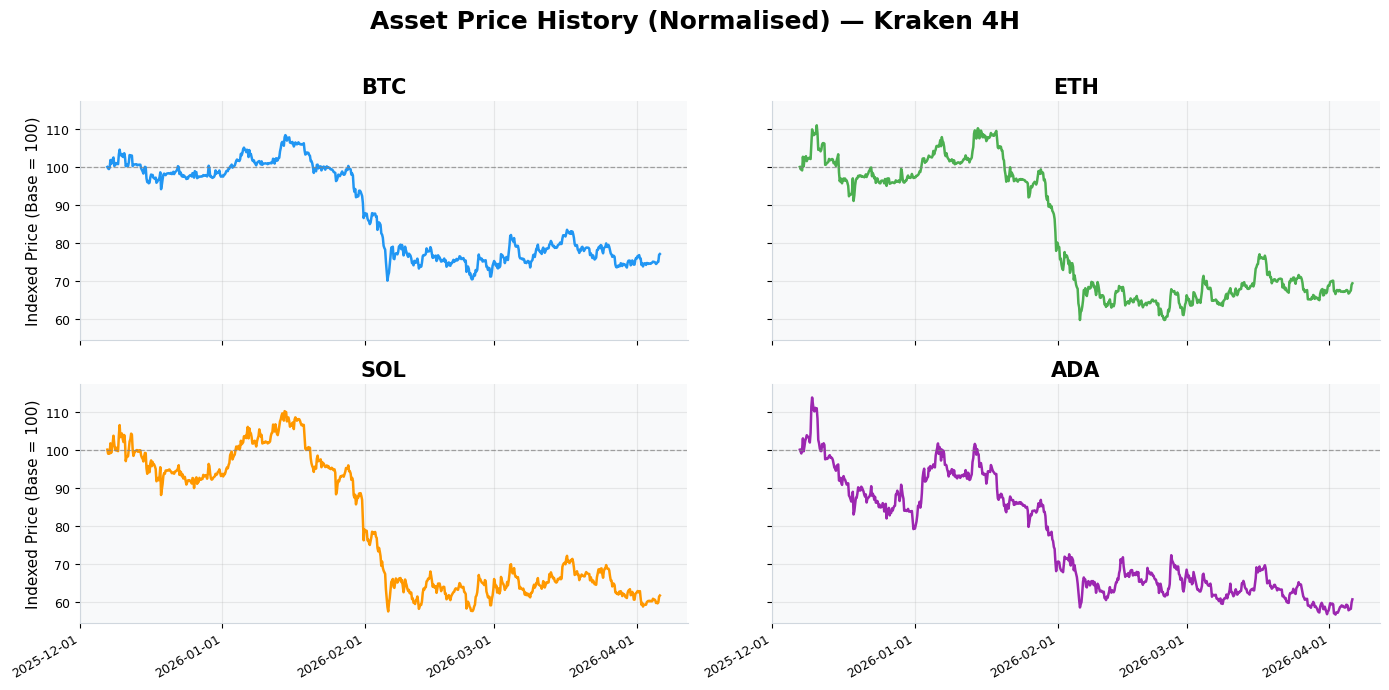

In [8]:
BAR_LABEL = '4H'

fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)
axes = axes.flatten()

default_colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#9C27B0', '#607D8B']
colors = default_colors[:len(prices.columns)]

normed_series = {
    ticker: prices[ticker] / prices[ticker].iloc[0] * 100
    for ticker in prices.columns
}

y_min = min(series.min() for series in normed_series.values()) - 2
y_max = max(series.max() for series in normed_series.values()) + 2

for i, (ax, ticker, color) in enumerate(zip(axes, prices.columns, colors)):
    s = normed_series[ticker]
    ax.plot(s.index, s.values, color=color, lw=1.8)
    ax.axhline(100, color='gray', ls='--', lw=0.9, alpha=0.7)
    ax.set_title(ticker, fontsize=15, fontweight='bold')
    ax.set_ylim(y_min, y_max)
    ax.grid(True, alpha=0.25)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if i % 2 == 0:
        ax.set_ylabel('Indexed Price (Base = 100)', fontsize=11)

for ax in axes[len(prices.columns):]:
    ax.axis('off')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=6))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

fig.suptitle(f'Asset Price History (Normalised) — Kraken {BAR_LABEL}', fontsize=18, fontweight='bold', y=0.98)
fig.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

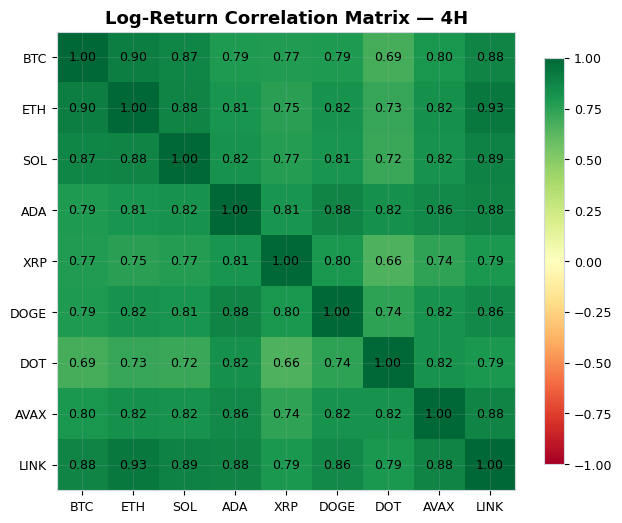

In [9]:
log_returns = np.log(prices / prices.shift(1)).dropna()
corr = log_returns.corr()

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax, shrink=0.82)

labels = list(corr.columns)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

ax.set_title(f'Log-Return Correlation Matrix — {BAR_LABEL}', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Cointegration Screening

A pair is considered tradeable only if it passes **all four** filters below:

| Test | What it checks | Threshold |
|---|---|---|
| **Engle-Granger** | Whether the two log-price series are cointegrated | p-value < threshold |
| **Johansen trace test** | Whether a system-based cointegration test also confirms the relationship | 95% critical value |
| **OU half-life** | Whether the spread mean-reverts on a tradeable horizon | bounded window |
| **ADF on spread** | Whether the constructed spread itself looks stationary | p-value < threshold |

The notebook reports both the raw diagnostics and the final pass/fail flag.

In [10]:
screening_results = screen_pairs(
    prices,
    eg_pvalue_threshold=0.15,
    min_halflife_days=1.0,
    max_halflife_days=90.0,
    adf_pvalue_threshold=0.10,
    bar_hours=BAR_HOURS,   # converts bar-count OU half-life to calendar days
)

rows = []
for r in screening_results:
    rows.append({
        'Pair':              f'{r.asset_a} / {r.asset_b}',
        'EG p-value':        r.eg_pvalue,
        'Johansen':          'PASS' if r.johansen_cointegrated else 'FAIL',
        'Half-life (days)':  r.half_life_days,
        'Hedge ratio':       r.hedge_ratio,
        'ADF p-value':       r.adf_pvalue,
        'Valid':             'YES' if r.is_valid else '',
    })

screen_df = pd.DataFrame(rows)
if not screen_df.empty:
    display(screen_df.style.format({
        'EG p-value': '{:.4f}',
        'Half-life (days)': '{:.1f}',
        'Hedge ratio': '{:.4f}',
        'ADF p-value': '{:.4f}',
    }))
else:
    print("No pairs were screened.")

valid_pairs = [r for r in screening_results if r.is_valid]
print(f"\nValid pairs found: {len(valid_pairs)}")

,Pair,EG p-value,Johansen,Half-life (days),Hedge ratio,ADF p-value,Valid
0,XRP / DOGE,0.0020,PASS,1.9,1.0025,0.0004,YES
1,BTC / SOL,0.0061,PASS,1.6,0.6296,0.0012,YES
2,BTC / ETH,0.0133,PASS,2.9,0.6637,0.0029,YES
3,ADA / XRP,0.0305,FAIL,3.5,1.0363,0.0075,
4,ADA / DOGE,0.0429,FAIL,3.8,1.0580,0.0112,
5,ETH / LINK,0.0551,PASS,4.7,1.0590,0.0150,YES
6,SOL / DOGE,0.0607,FAIL,5.1,1.1958,0.0170,
7,XRP / AVAX,0.0846,PASS,2.6,0.9778,0.0255,YES
8,SOL / XRP,0.0995,PASS,2.2,1.1967,0.0309,YES
9,SOL / LINK,0.1022,PASS,3.8,1.1169,0.0319,YES



Valid pairs found: 7


---
## 3. Spread Construction & Z-score Signals

For each valid pair `(A, B)` with OLS hedge ratio `beta`:

    Spread = log(Price_A) - beta * log(Price_B)
    Z-score = (Spread - rolling_mean) / rolling_std

**Trading rules**
- Enter **long spread** when z < -2.0
- Enter **short spread** when z > +2.0
- Exit when |z| < 0.5
- Stop out when |z| > 3.5

The pair shown below is the strongest surviving candidate in the current sample.

In [11]:
if not valid_pairs:
    print("No valid pairs found under the current settings. Try broadening the universe, relaxing thresholds, or extending the sample.")
else:
    signal_cfg = SignalConfig(entry_z=2.0, exit_z=0.5, stop_z=3.5, lookback=LOOKBACK_BARS)

    demo_pair = min(valid_pairs, key=lambda r: r.eg_pvalue)
    A, B = demo_pair.asset_a, demo_pair.asset_b
    beta = demo_pair.hedge_ratio

    spread = compute_spread(prices[A], prices[B], beta)
    signals_df = generate_signals(spread, signal_cfg)

    print(f"Demo pair:     {A} / {B}")
    print(f"Hedge ratio:   {beta:.4f}")
    print(f"Half-life:     {demo_pair.half_life_days:.1f} calendar days")
    print(f"EG p-value:    {demo_pair.eg_pvalue:.4f}")
    print(f"ADF p-value:   {demo_pair.adf_pvalue:.4f}")
    print(f"Active bars:   {(signals_df['position'] != 0).sum():,}")
    print(f"Z-score lookback: {LOOKBACK_BARS} bars ≈ {LOOKBACK_BARS * BAR_HOURS / 24:.0f} calendar days")

Demo pair:     XRP / DOGE
Hedge ratio:   1.0025
Half-life:     1.9 calendar days
EG p-value:    0.0020
ADF p-value:   0.0004
Active bars:   172
Z-score lookback: 120 bars ≈ 20 calendar days


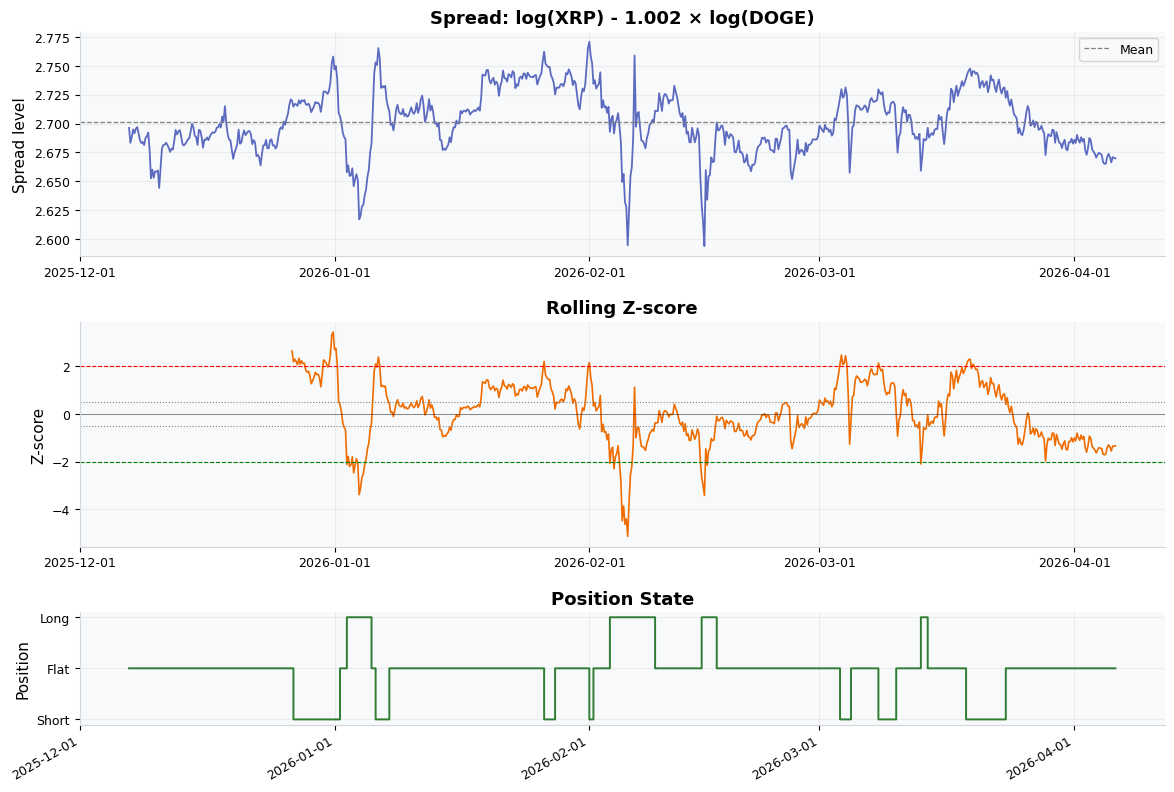

In [12]:
if valid_pairs:
    fig = plt.figure(figsize=(14, 9))
    gs = gridspec.GridSpec(3, 1, height_ratios=[2, 2, 1], hspace=0.35)

    ax1 = fig.add_subplot(gs[0])
    ax1.plot(spread.index, spread.values, color='#5C6BC0', lw=1.3)
    ax1.axhline(spread.mean(), color='gray', ls='--', lw=0.9, label='Mean')
    ax1.set_title(f'Spread: log({A}) - {beta:.3f} × log({B})', fontweight='bold')
    ax1.set_ylabel('Spread level')
    ax1.legend(fontsize=9)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    z = signals_df['zscore']
    ax2.plot(z.index, z.values, color='#EF6C00', lw=1.2)
    ax2.axhline(2.0, color='red', ls='--', lw=0.8)
    ax2.axhline(-2.0, color='green', ls='--', lw=0.8)
    ax2.axhline(0.5, color='gray', ls=':', lw=0.8)
    ax2.axhline(-0.5, color='gray', ls=':', lw=0.8)
    ax2.axhline(0, color='black', ls='-', lw=0.6, alpha=0.5)
    ax2.set_title('Rolling Z-score', fontweight='bold')
    ax2.set_ylabel('Z-score')
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    ax3 = fig.add_subplot(gs[2], sharex=ax1)
    ax3.step(signals_df.index, signals_df['position'], where='post', color='#2E7D32', lw=1.4)
    ax3.set_title('Position State', fontweight='bold')
    ax3.set_ylabel('Position')
    ax3.set_yticks([-1, 0, 1])
    ax3.set_yticklabels(['Short', 'Flat', 'Long'])
    ax3.spines['top'].set_visible(False)
    ax3.spines['right'].set_visible(False)

    ax3.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=6))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(ax3.get_xticklabels(), rotation=30, ha='right')

    plt.tight_layout()
    plt.show()

---
## 4. Position Sizing — Fractional Kelly

The strategy uses a **fractional Kelly** overlay to scale exposure based on the recent signal-to-noise ratio of spread changes.

    Full Kelly:       f* = mean_return / variance
    Fractional Kelly: f  = 0.25 * f*

For presentation purposes, the important point is that position size is **dynamic**, **capped**, and linked to the recent quality of the spread process rather than being fixed notional on every trade.

In [13]:
if valid_pairs:
    sizing_cfg = SizingConfig(capital=CAPITAL, max_position_pct=0.20, kelly_fraction=0.25)
    sizing_df = kelly_size(signals_df, prices[A], prices[B], beta, sizing_cfg)

    print(f"Capital:          ${CAPITAL:,.0f}")
    print(f"Max per pair:     ${CAPITAL * 0.20:,.0f}  (20% cap)")
    print("Kelly fraction:   25% of full Kelly")
    print()

    active_days = sizing_df.dropna(subset=['pos_a_usd', 'pos_b_usd', 'kelly_f'])
    active_days = active_days[
        (active_days['pos_a_usd'] != 0) | (active_days['pos_b_usd'] != 0)
    ].head(10)

    if not active_days.empty:
        pretty = active_days[['pos_a_usd', 'pos_b_usd', 'dollar_exposure', 'kelly_f', 'rolling_vol']].copy()
        pretty[['pos_a_usd', 'pos_b_usd', 'dollar_exposure']] = pretty[['pos_a_usd', 'pos_b_usd', 'dollar_exposure']].round(2)
        pretty[['kelly_f', 'rolling_vol']] = pretty[['kelly_f', 'rolling_vol']].round(4)
        display(pretty)
    else:
        print("No active sized trades for the selected pair under the current settings.")

Capital:          $100,000
Max per pair:     $20,000  (20% cap)
Kelly fraction:   25% of full Kelly



,pos_a_usd,pos_b_usd,dollar_exposure,kelly_f,rolling_vol
time,,,,,
2025-12-27 00:00:00+00:00,-20000.0,20050.0,20000.0,0.2,0.0053
2025-12-27 04:00:00+00:00,-20000.0,20050.0,20000.0,0.2,0.0053
2025-12-27 08:00:00+00:00,-20000.0,20050.0,20000.0,0.2,0.0052
2025-12-27 12:00:00+00:00,-20000.0,20050.0,20000.0,0.2,0.0047
2025-12-27 16:00:00+00:00,-20000.0,20050.0,20000.0,0.2,0.0047
2025-12-27 20:00:00+00:00,-20000.0,20050.0,20000.0,0.2,0.0047
2025-12-28 00:00:00+00:00,-20000.0,20050.0,20000.0,0.2,0.0045
2025-12-28 04:00:00+00:00,-20000.0,20050.0,20000.0,0.2,0.0042
2025-12-28 08:00:00+00:00,-20000.0,20050.0,20000.0,0.2,0.0041


---
## 5. Backtest

The backtest is **vectorized** and computes PnL from the actual asset legs rather than from spread changes alone.

Key assumptions:
- **7 bps transaction costs**
- **3 bps slippage**
- **$100k starting capital**
- **25% drawdown kill-switch**

This section shows both summary metrics and a polished path chart for the selected demo pair.

In [14]:
if valid_pairs:
    bt_cfg = BacktestConfig(capital=CAPITAL, transaction_cost_bps=7.0, slippage_bps=3.0)

    result = run_backtest(
        prices[A], prices[B],
        signals_df, sizing_df,
        beta, A, B, bt_cfg
    )

    metrics = pd.DataFrame({
        "Metric": [
            "Annualized Return", "Sharpe Ratio", "Max Drawdown",
            "Calmar Ratio", "Number of Trades", "Win Rate", "Final Capital"
        ],
        "Value": [
            f"{result.annualized_return * 100:.2f}%",
            f"{result.sharpe_ratio:.2f}",
            f"{result.max_drawdown * 100:.2f}%",
            f"{result.calmar_ratio}",
            f"{result.num_trades}",
            f"{result.win_rate * 100:.1f}%",
            f"${result.equity_curve.iloc[-1]:,.0f}",
        ],
    })
    display(metrics)

,Metric,Value
0,Annualized Return,8.84%
1,Sharpe Ratio,2.34
2,Max Drawdown,-1.37%
3,Calmar Ratio,6.437
4,Number of Trades,11
5,Win Rate,54.5%
6,Final Capital,"$102,828"


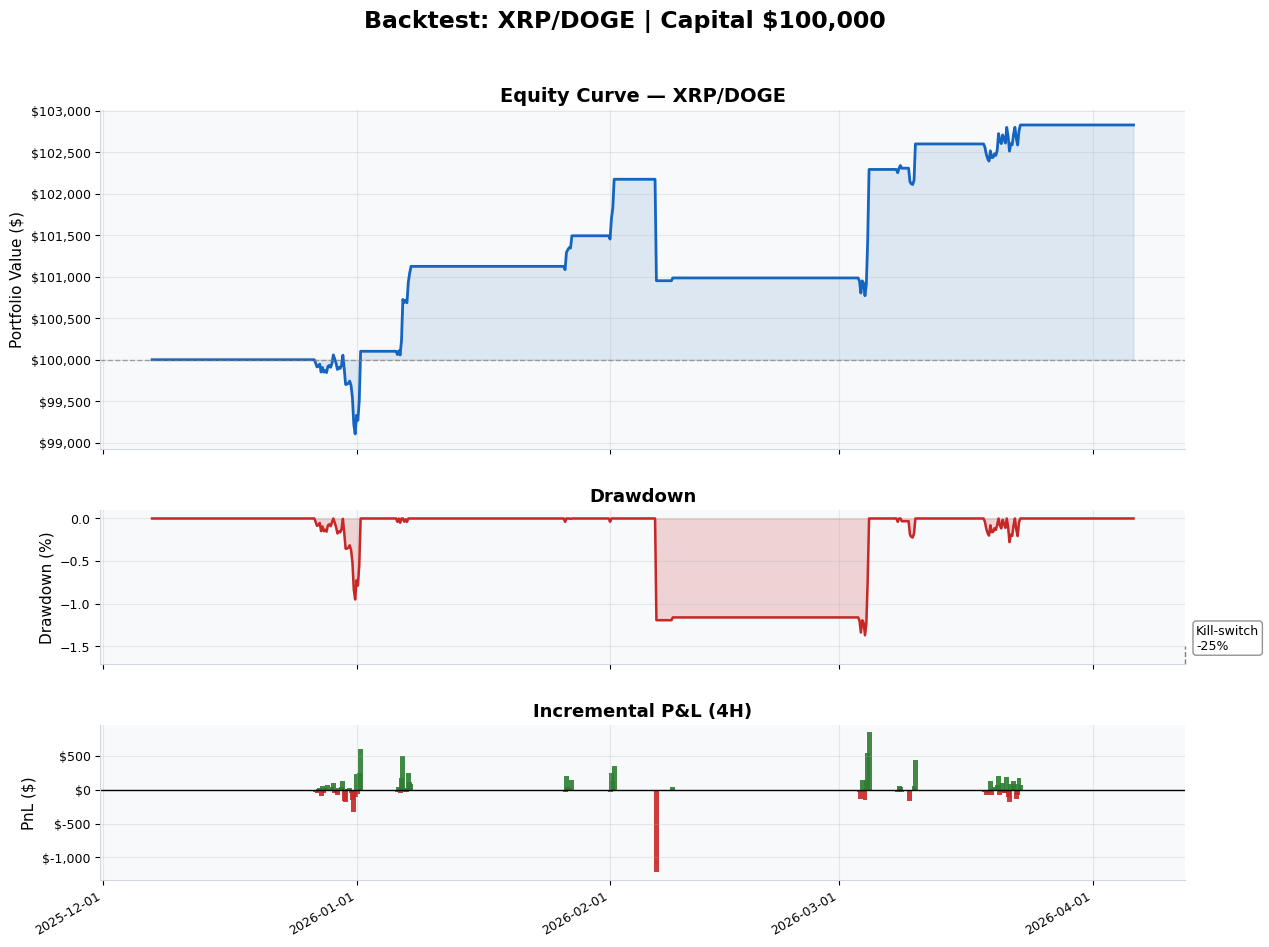

In [18]:
BAR_INTERVAL_MIN = 240

if valid_pairs:
    import os
    os.makedirs('plots', exist_ok=True)

    fig, axes = plt.subplots(
        3, 1,
        figsize=(14, 10),
        sharex=True,
        gridspec_kw={'height_ratios': [2.2, 1, 1], 'hspace': 0.28}
    )

    eq = result.equity_curve

    # Equity curve
    axes[0].plot(eq.index, eq.values, color='#1565C0', lw=2)
    axes[0].fill_between(eq.index, eq.values, CAPITAL, color='#1565C0', alpha=0.12)
    axes[0].axhline(CAPITAL, color='gray', ls='--', lw=1, alpha=0.7)
    axes[0].set_title(f'Equity Curve — {A}/{B}', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Portfolio Value ($)', fontsize=11)
    axes[0].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[0].grid(True, alpha=0.25)
    axes[0].spines['top'].set_visible(False)
    axes[0].spines['right'].set_visible(False)

    # Drawdown
    rolling_max = eq.cummax()
    drawdown = (eq - rolling_max) / rolling_max * 100
    axes[1].plot(drawdown.index, drawdown.values, color='#C62828', lw=1.8)
    axes[1].fill_between(drawdown.index, drawdown.values, 0, color='#C62828', alpha=0.18)

    actual_min_dd = float(drawdown.min())
    lower = min(actual_min_dd * 1.25, -0.5)
    upper = 0.10
    axes[1].set_ylim(lower, upper)

    axes[1].set_title('Drawdown', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Drawdown (%)', fontsize=11)
    axes[1].grid(True, alpha=0.25)
    axes[1].spines['top'].set_visible(False)
    axes[1].spines['right'].set_visible(False)

    # Ghost kill-switch reference
    axes[1].text(
        1.01, 0.08,
        'Kill-switch\n-25%',
        transform=axes[1].transAxes,
        ha='left',
        va='bottom',
        fontsize=9,
        color='black',
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor='gray', alpha=0.85)
    )
    axes[1].plot(
        [1.0, 1.0], [0.0, 0.12],
        transform=axes[1].transAxes,
        color='black',
        ls='--',
        lw=1,
        alpha=0.5,
        clip_on=False
    )

    # Incremental PnL
    pnl = result.daily_pnl
    bar_width = 0.6 if BAR_INTERVAL_MIN == 240 else 0.8
    colors_bar = ['#2E7D32' if v > 0 else '#C62828' for v in pnl.values]
    axes[2].bar(pnl.index, pnl.values, color=colors_bar, width=bar_width, alpha=0.9)
    axes[2].axhline(0, color='black', lw=1)
    axes[2].set_title(f'Incremental P&L ({BAR_LABEL})', fontsize=13, fontweight='bold')
    axes[2].set_ylabel('PnL ($)', fontsize=11)
    axes[2].yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[2].grid(True, alpha=0.25)
    axes[2].spines['top'].set_visible(False)
    axes[2].spines['right'].set_visible(False)

    axes[2].xaxis.set_major_locator(mdates.AutoDateLocator(minticks=4, maxticks=6))
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
    plt.setp(axes[2].get_xticklabels(), rotation=30, ha='right')

    fig.suptitle(f'Backtest: {A}/{B} | Capital ${CAPITAL:,.0f}', fontsize=17, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig(f'plots/{A}_{B}_demo.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 6. Full Universe Results

All 7 valid pairs are backtested below using identical parameters. Results are sorted by Sharpe ratio.

Four pairs clear Sharpe > 2.0 with max drawdown under −1.5%:

- **BTC/SOL** — best risk-adjusted profile overall (Sharpe 3.66, max DD −0.3%)
- **XRP/AVAX** — highest return (+15.1% ann.) and Calmar (24.2); right-skewed payoffs
- **BTC/ETH** — steady Sharpe 2.82, consistent with a well-known structural relationship
- **XRP/DOGE** — highest win rate (55%) of the group; Sharpe 2.34

SOL/XRP shows a positive Sharpe (1.41) but a wider drawdown (−1.7%) and warrants closer monitoring. ETH/LINK is the weakest pair in this window.


In [19]:
sizing_cfg = SizingConfig(capital=CAPITAL, max_position_pct=0.20, kelly_fraction=0.25)
bt_cfg = BacktestConfig(capital=CAPITAL, transaction_cost_bps=7.0, slippage_bps=3.0)
signal_cfg = SignalConfig(entry_z=2.0, exit_z=0.5, stop_z=3.5, lookback=LOOKBACK_BARS)

all_results = []
for pair_res in valid_pairs:
    a, b = pair_res.asset_a, pair_res.asset_b
    sp = compute_spread(prices[a], prices[b], pair_res.hedge_ratio)
    sig = generate_signals(sp, signal_cfg)
    siz = kelly_size(sig, prices[a], prices[b], pair_res.hedge_ratio, sizing_cfg)
    res = run_backtest(prices[a], prices[b], sig, siz, pair_res.hedge_ratio, a, b, bt_cfg)
    all_results.append(res)

if not all_results:
    print("No valid pairs to backtest across the full universe.")

In [20]:
if all_results:
    summary = pd.DataFrame([{
        'Pair':          f'{r.pair[0]}/{r.pair[1]}',
        'Ann. Return':   f'{r.annualized_return*100:.1f}%',
        'Sharpe':        f'{r.sharpe_ratio:.2f}',
        'Max Drawdown':  f'{r.max_drawdown*100:.1f}%',
        'Calmar':        str(r.calmar_ratio),
        'Win Rate':      f'{r.win_rate*100:.0f}%',
        'Trades':        r.num_trades,
        'Final Capital': f'${r.equity_curve.iloc[-1]:,.0f}',
    } for r in all_results]).sort_values('Sharpe', ascending=False)

    display(summary)

,Pair,Ann. Return,Sharpe,Max Drawdown,Calmar,Win Rate,Trades,Final Capital
1,BTC/SOL,4.8%,3.66,-0.3%,16.945,46%,11,"$101,553"
4,XRP/AVAX,15.1%,3.49,-0.6%,24.198,33%,9,"$104,741"
2,BTC/ETH,4.9%,2.82,-0.8%,6.321,46%,11,"$101,597"
0,XRP/DOGE,8.8%,2.34,-1.4%,6.437,55%,11,"$102,828"
5,SOL/XRP,6.4%,1.41,-1.7%,3.717,36%,11,"$102,061"
6,SOL/LINK,1.2%,0.43,-1.2%,0.997,38%,8,"$100,393"
3,ETH/LINK,-1.6%,-0.69,-1.2%,-1.323,40%,5,"$99,482"


---
## 7. Robustness Notes

### What the current pipeline does well
- **Relative-value framing:** trades the spread rather than outright direction
- **Dual cointegration confirmation:** Engle-Granger + Johansen reduces false positives
- **Tradeability filter:** OU half-life eliminates relationships that revert too slowly
- **Risk controls:** capped Kelly sizing, modeled costs, and a drawdown kill-switch

### Known limitations / next upgrades
| Limitation | Why it matters | Natural next step |
|---|---|---|
| Static hedge ratio | crypto relationships can drift over time | rolling OLS or Kalman hedge ratio |
| Full-sample screening | pair quality can change by regime | walk-forward screening |
| Small / curated universe | stat-arb needs breadth | expand to more liquid Kraken USD pairs |
| Incremental PnL only | trade-level insight is limited | add trade-level attribution and duration analysis |

---
## 8. Live Signal Check

In [21]:
signal_cfg = SignalConfig(entry_z=2.0, exit_z=0.5, stop_z=3.5, lookback=LOOKBACK_BARS)

if not valid_pairs:
    print("No live signals to show because no pairs passed the screening step.")
else:
    print('Current live signals (as of last bar):\n')
    for pair_res in valid_pairs:
        a, b = pair_res.asset_a, pair_res.asset_b
        sp = compute_spread(prices[a], prices[b], pair_res.hedge_ratio)
        sig = generate_signals(sp, signal_cfg)
        live = get_current_signal(sig, a, b, pair_res.hedge_ratio)
        label = {1: 'LONG SPREAD', -1: 'SHORT SPREAD', 0: 'FLAT'}[live.position]

        print(f'  {a}/{b}')
        print(f'    Date:        {live.date}')
        print(f'    Z-score:     {live.zscore:+.3f}')
        print(f'    Position:    {label}')
        print(f'    Hedge ratio: {live.hedge_ratio:.4f}\n')

Current live signals (as of last bar):

  XRP/DOGE
    Date:        2026-04-06 00:00:00+00:00
    Z-score:     -1.341
    Position:    FLAT
    Hedge ratio: 1.0025

  BTC/SOL
    Date:        2026-04-06 00:00:00+00:00
    Z-score:     +2.347
    Position:    SHORT SPREAD
    Hedge ratio: 0.6296

  BTC/ETH
    Date:        2026-04-06 00:00:00+00:00
    Z-score:     -0.062
    Position:    FLAT
    Hedge ratio: 0.6637

  ETH/LINK
    Date:        2026-04-06 00:00:00+00:00
    Z-score:     +1.006
    Position:    FLAT
    Hedge ratio: 1.0590

  XRP/AVAX
    Date:        2026-04-06 00:00:00+00:00
    Z-score:     -2.084
    Position:    LONG SPREAD
    Hedge ratio: 0.9778

  SOL/XRP
    Date:        2026-04-06 00:00:00+00:00
    Z-score:     -0.137
    Position:    FLAT
    Hedge ratio: 1.1967

  SOL/LINK
    Date:        2026-04-06 00:00:00+00:00
    Z-score:     -1.546
    Position:    LONG SPREAD
    Hedge ratio: 1.1169



---
## References

- Engle & Granger (1987). *Co-Integration and Error Correction.* Econometrica.
- Johansen (1991). *Estimation and Hypothesis Testing of Cointegration Vectors.* Econometrica.
- Avellaneda & Lee (2010). *Statistical Arbitrage in the U.S. Equities Market.* Quantitative Finance.
- Kelly (1956). *A New Interpretation of Information Rate.* Bell System Technical Journal.